# Running PHANTOM (Octave) inside a Jupyter Notebook

This notebook demonstrates that **phantom** (the MATLAB/Octave dark-matter
halo toolbox) can be run interactively from Jupyter using the native
`octave_kernel`, without leaving a Python/Jupyter-based workflow.

Two options exist to get an Octave kernel in Jupyter:

1. `octave_kernel` (pip/conda, thin wrapper around a system Octave process)
2. `xeus-octave` (conda-forge, native C++ Jupyter protocol kernel)

This notebook assumes you already have **Octave installed** on your system.
The first cell below is a **setup/kernel cell** — run it once from a terminal
or an initial Python cell if `octave_kernel` is not yet registered with Jupyter.


In [ ]:
# --- SETUP CELL (Python) ---
# Run this once if the Octave kernel is not yet installed/registered.
# Safe to skip if you already ran `python -m octave_kernel install`.

# !pip install octave_kernel
# !python -m octave_kernel install --user

# Alternative (native kernel, via conda/mamba):
# !mamba install -c conda-forge xeus-octave -y

print("If the 'Octave' kernel does not appear in the Jupyter kernel list, "
      "run the commented install lines above, then restart Jupyter.")


---
## Switch kernel to Octave

In Jupyter: **Kernel → Change Kernel → Octave**

All cells from here onward run natively in Octave, calling phantom functions
exactly as you would in MATLAB.


In [21]:
# installing the phantom octave

pkg install "https://github.com/matc-thaher/PHANTOM_oct/archive/refs/heads/main.zip"

In [3]:
pkg load phantom-octave

# for checking the available list of packages

#pkg list

In [9]:
% --- Octave cell: build a cosmology structure ---
cosmo = cosmology('Planck18');

printf('h    = %.4f\n', cosmo.h);
printf('Om_m = %.4f\n', cosmo.Omega_m);
printf('sigma8 = %.4f\n', cosmo.sigma8);


h    = 0.6766
Om_m = 0.3111
sigma8 = 0.8102


In [15]:
% --- Octave cell: linear power spectrum ---
k = logspace(-3, 2, 200)';   % h/Mpc
Pk = cosmo.Pk(k, 0);

printf('P(k) computed on %d points.\n', numel(k));
printf('P(k=0.1 h/Mpc) = %.4e (Mpc/h)^3\n', Pk(find(k >= 0.1, 1)));


P(k) computed on 200 points.
P(k=0.1 h/Mpc) = 5.5603e+03 (Mpc/h)^3


Figure saved as phantom_octave_notebook_demo.png


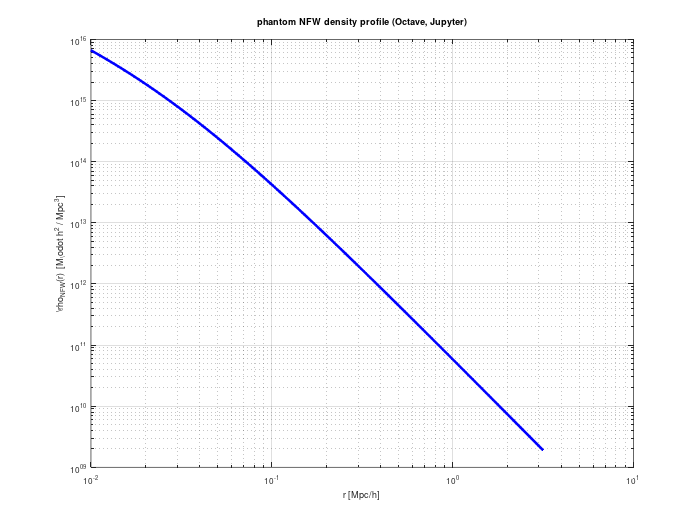

In [17]:
% --- Octave cell: quick NFW density profile + plot ---
Mh    = 1e12;      % Msun/h
c_nfw = 8.0;
z_l   = 0.0;
Delta = 200;

rho_c   = cosmo.rho_crit0 * cosmo.E(z_l)^2;
R_Delta = (3*Mh / (4*pi*Delta*rho_c))^(1/3);   % Mpc/h
rs      = R_Delta / c_nfw;
fc      = log(1+c_nfw) - c_nfw/(1+c_nfw);
rhos    = Mh / (4*pi*rs^3*fc);

r  = logspace(-2, 0.5, 200)';                  % Mpc/h
rho_nfw = NFW_profile(r, rhos, rs);

loglog(r, rho_nfw, 'b-', 'LineWidth', 2);
xlabel('r [Mpc/h]');
ylabel('\\rho_{NFW}(r)  [M_\\odot h^2 / Mpc^3]');
title('phantom NFW density profile (Octave, Jupyter)');
grid on;

print('-dpng', 'phantom_octave_notebook_demo.png');
disp('Figure saved as phantom_octave_notebook_demo.png');


---
## Notes

- All function calls above (`cosmology`, `power_spectrum`, `NFW_profile`)
  are identical to their MATLAB usage — no code changes are needed to move
  between MATLAB, standalone Octave, and Octave-in-Jupyter.
- If using `xeus-octave` instead of `octave_kernel`, no changes to the code
  cells are required; only the kernel backend differs.
